**Zomato Data Analysis Using Python**

It is important to understand customer preferences and restaurant trends to make informed business decisions in food industry. 

Do more restaurants provide online delivery compared to offline services?

which types of restaurants are most favoured by the general public?

what price range do couples prefer for dining out?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Zomato-data- (1).csv")
print(df.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


Data Cleaning and Preparation Before moving further we need to clean and process the data

1. Convert the rate column to a float by removing denominator characters

dataframe['rate] = dataframe['rate'].apply(handleRate)

Applies the handleRate function to clean and convert each rating value in the 'rate' column.

In [5]:
def handleRate(value):
    value = str(value).split('/')
    value = value[0].strip()
    return float(value)

df['rate'] = df['rate'].apply(handleRate)
print(df.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [6]:
# Getting summary of the dataframe using info() method
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 12.0 KB
None


In [7]:
print(df.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


**Exploring Restaurant Types**
1. Let's see the listed_in(type) column to identify popular categories.

Text(0.5, 0, 'Types of Restaurants')

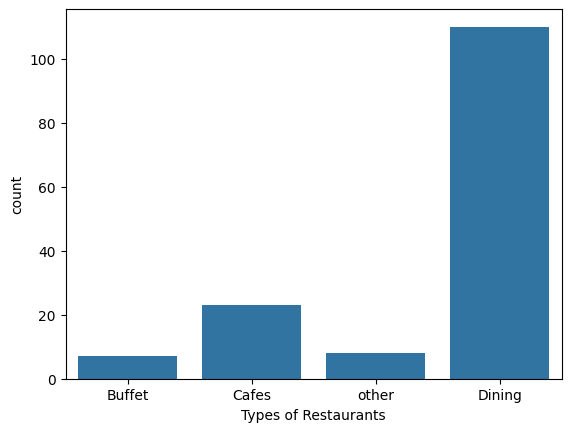

In [8]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel('Types of Restaurants')

In [10]:
# Conclusion: The majority of the restaurants fall into dining category

Text(0, 0.5, 'Votes')

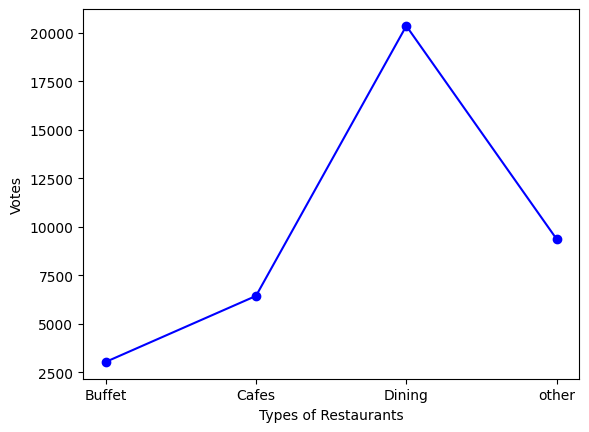

In [11]:
#votes by restaurant type
#Here we get the count of votes for each category
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c='blue',marker='o')
plt.xlabel('Types of Restaurants')
plt.ylabel('Votes')

In [12]:
#Conclusion: Dining restaurants are preferred by a larger number of individuals

In [ ]:
#identify the most voted restaurant
#find the restaurant with the highest number of votes
max_votes = df['votes'].max()
restaurant_with_max_votes = df.loc[df['votes'] == max_votes, 'name']

print("Restaurant(s) with the maximum votes: ")
print(restaurant_with_max_votes)

Restaurant(s) withe the maximum votes: 
38    Empire Restaurant
Name: name, dtype: str


<Axes: xlabel='online_order', ylabel='count'>

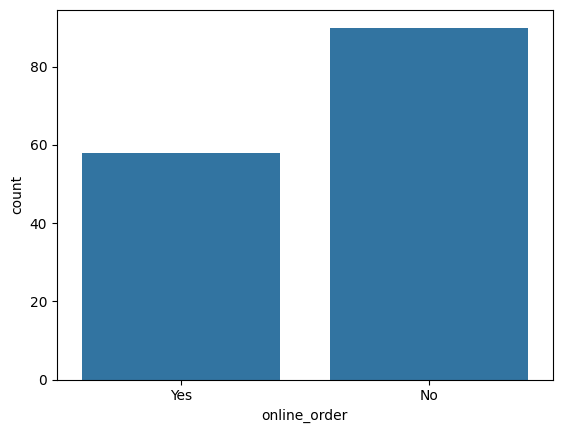

In [14]:
#Step 6: Online Order Avaibility 
#Exploring the online_order column to see how many restaurants offer online ordering.
sns.countplot(x=df['online_order'])

In [16]:
#Conclusion: This suggests that a majority of the restaurants do not accept online orders.

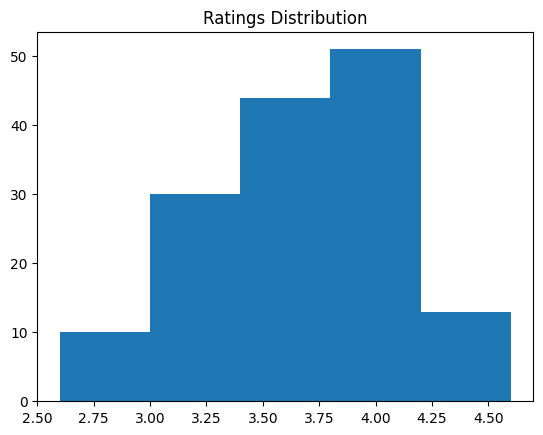

In [17]:
#Step 7: Analyze Ratings
#Checking the distribution of ratings from the rate column
plt.hist(df['rate'],bins=5)
plt.title('Ratings Distribution')
plt.show()

In [19]:
#Conclusion: Majority of restaurants received ratings ranging from 3.5 to 4

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

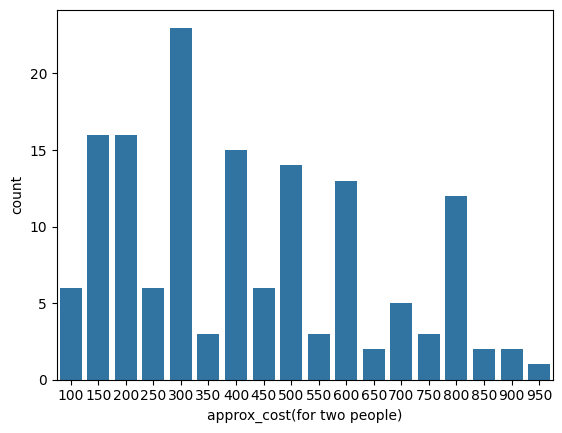

In [20]:
#Step 8: Approximate Cost for Couples
#Analyze the approx_cost (for two people) column to find the preferred price range.

couple_data = df['approx_cost(for two people)']
sns.countplot(x = couple_data)

In [22]:
#Conclusion: The Majority of couples prefer restaurants with an approximate cost of 300 rupees

In [23]:
#Step 9: Rating Comparisions- Online vs Offline orders

#Compare ratings between restaurants that accept online orders and those that don't

<Axes: xlabel='online_order', ylabel='rate'>

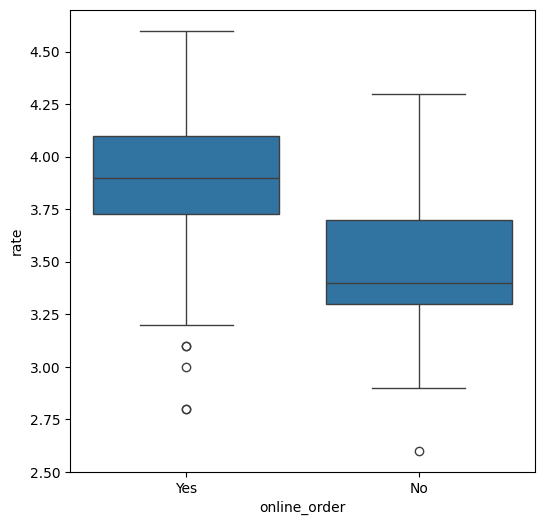

In [24]:
plt.figure(figsize=(6,6))
sns.boxplot(x='online_order',y='rate',data=df)